In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [10]:
PATH = "../data/"
filename = 'msmes.csv'
df = pd.read_csv(PATH + filename)
df.head()

,Business_Size,Business_Age,Industry_Type,Entity_Type,Monthly_GST_Sales,GST_Growth_Rate,GST_Filing_Delay,GST_Compliance_Rate,Monthly_UPI_Count,Monthly_UPI_Value,...,Monthly_Credit,Monthly_Debit,Cashflow_Volatility,Employee_Count,Payroll_Consistency,Vendor_Payment_Delay,Working_Capital_Cycle,EMI_Bounce_Count,PD_True,Default
0,Small,3.259143,Retail,Proprietorship,1.041611e+06,-0.105973,11.100083,0.930616,89,222313.252027,...,1.079347e+06,799912.170455,0.016356,27,0.975329,11.376241,34.511462,0,0.000059,0
1,Micro,1.043744,Manufacturing,LLP,1.185538e+05,0.148953,8.625211,1.000000,13,5981.733679,...,1.101660e+05,92536.163891,0.341500,7,0.849837,19.329942,102.988904,0,0.001164,0
2,Micro,7.300253,Agriculture,Proprietorship,5.511186e+05,0.110490,4.305277,0.959657,17,17563.091000,...,4.778285e+05,279259.848766,0.527937,4,0.799129,20.347545,78.429116,1,0.103713,1
3,Micro,26.798767,Retail,Proprietorship,1.669279e+05,-0.015217,3.290730,1.000000,59,80650.048906,...,1.557148e+05,130123.809195,0.382392,5,0.706147,7.669705,43.484573,0,0.000008,0
4,Micro,6.507175,Manufacturing,Partnership,8.990894e+05,0.127848,3.903448,0.931603,14,31292.801883,...,9.385547e+05,755815.166491,0.174035,5,0.707897,19.509115,103.379616,1,0.007137,0


## Dataset Overview

In [13]:
print("="*20)
print("DATASET OVERVIEW")
print("="*20)

print(f"Rows      : {df.shape[0]}")
print(f"Columns   : {df.shape[1]}")
print(f"Features  : {df.shape[1]-1}")
print(f"Target    : Default")

DATASET OVERVIEW
Rows      : 20000
Columns   : 22
Features  : 21
Target    : Default


## Data Types

In [15]:
print(df.dtypes)

Business_Size                str
Business_Age             float64
Industry_Type                str
Entity_Type                  str
Monthly_GST_Sales        float64
GST_Growth_Rate          float64
GST_Filing_Delay         float64
GST_Compliance_Rate      float64
Monthly_UPI_Count          int64
Monthly_UPI_Value        float64
Digital_Sales_Ratio      float64
Average_Bank_Balance     float64
Monthly_Credit           float64
Monthly_Debit            float64
Cashflow_Volatility      float64
Employee_Count             int64
Payroll_Consistency      float64
Vendor_Payment_Delay     float64
Working_Capital_Cycle    float64
EMI_Bounce_Count           int64
PD_True                  float64
Default                    int64
dtype: object


## Missing Values

In [18]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({"Missing Values": missing, 
                           "Percentage": (missing/len(df))*100})

missing_df = missing_df[missing_df["Missing Values"]>0]

if len(missing_df)==0:
    print("No Missing Values")
else:
    print(missing_df)

No Missing Values


## Summary Statistics

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Business_Age,20000.0,6.036024,5.726741e+00,1.000000e+00,1.729354,4.173219,8.298163,3.000000e+01
Monthly_GST_Sales,20000.0,730839.459288,1.143212e+06,5.000000e+04,211204.183517,407407.150369,806521.486920,2.000000e+07
GST_Growth_Rate,20000.0,0.121694,1.306087e-01,-3.820876e-01,0.033737,0.122825,0.210118,6.000000e-01
GST_Filing_Delay,20000.0,10.432022,8.654410e+00,7.540673e-02,4.422736,8.092445,13.755374,1.204730e+02
GST_Compliance_Rate,20000.0,0.935686,6.106370e-02,3.319837e-01,0.901887,0.947277,0.988041,1.000000e+00
Monthly_UPI_Count,20000.0,35.472850,1.938290e+01,2.000000e+00,20.000000,34.000000,46.000000,1.480000e+02
Monthly_UPI_Value,20000.0,50390.109748,3.640073e+04,1.535793e+03,23441.272309,41506.735486,68668.740466,3.149230e+05
Digital_Sales_Ratio,20000.0,0.686293,1.927504e-01,2.660055e-02,0.562026,0.722712,0.838700,9.989496e-01
Average_Bank_Balance,20000.0,105481.269050,2.841510e+05,2.035542e+03,19774.729611,40221.566320,89538.161697,7.197248e+06
Monthly_Credit,20000.0,694286.494638,1.087307e+06,4.250572e+04,199538.532183,385989.864028,765475.384748,2.001201e+07


## Target Distribution

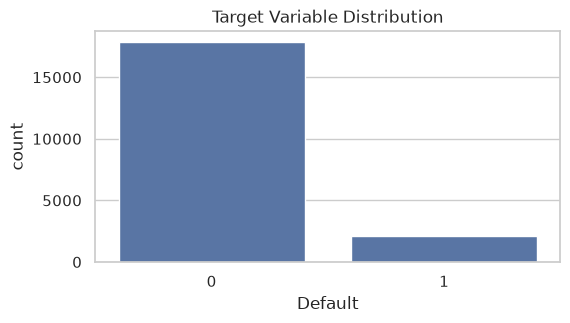

Default
0    89.31
1    10.69
Name: proportion, dtype: float64


In [23]:
plt.figure(figsize=(6,3))
sns.countplot(data=df, x="Default")
plt.title("Target Variable Distribution")
plt.show()
print(df["Default"].value_counts(normalize=True)*100)

## Numerical Features

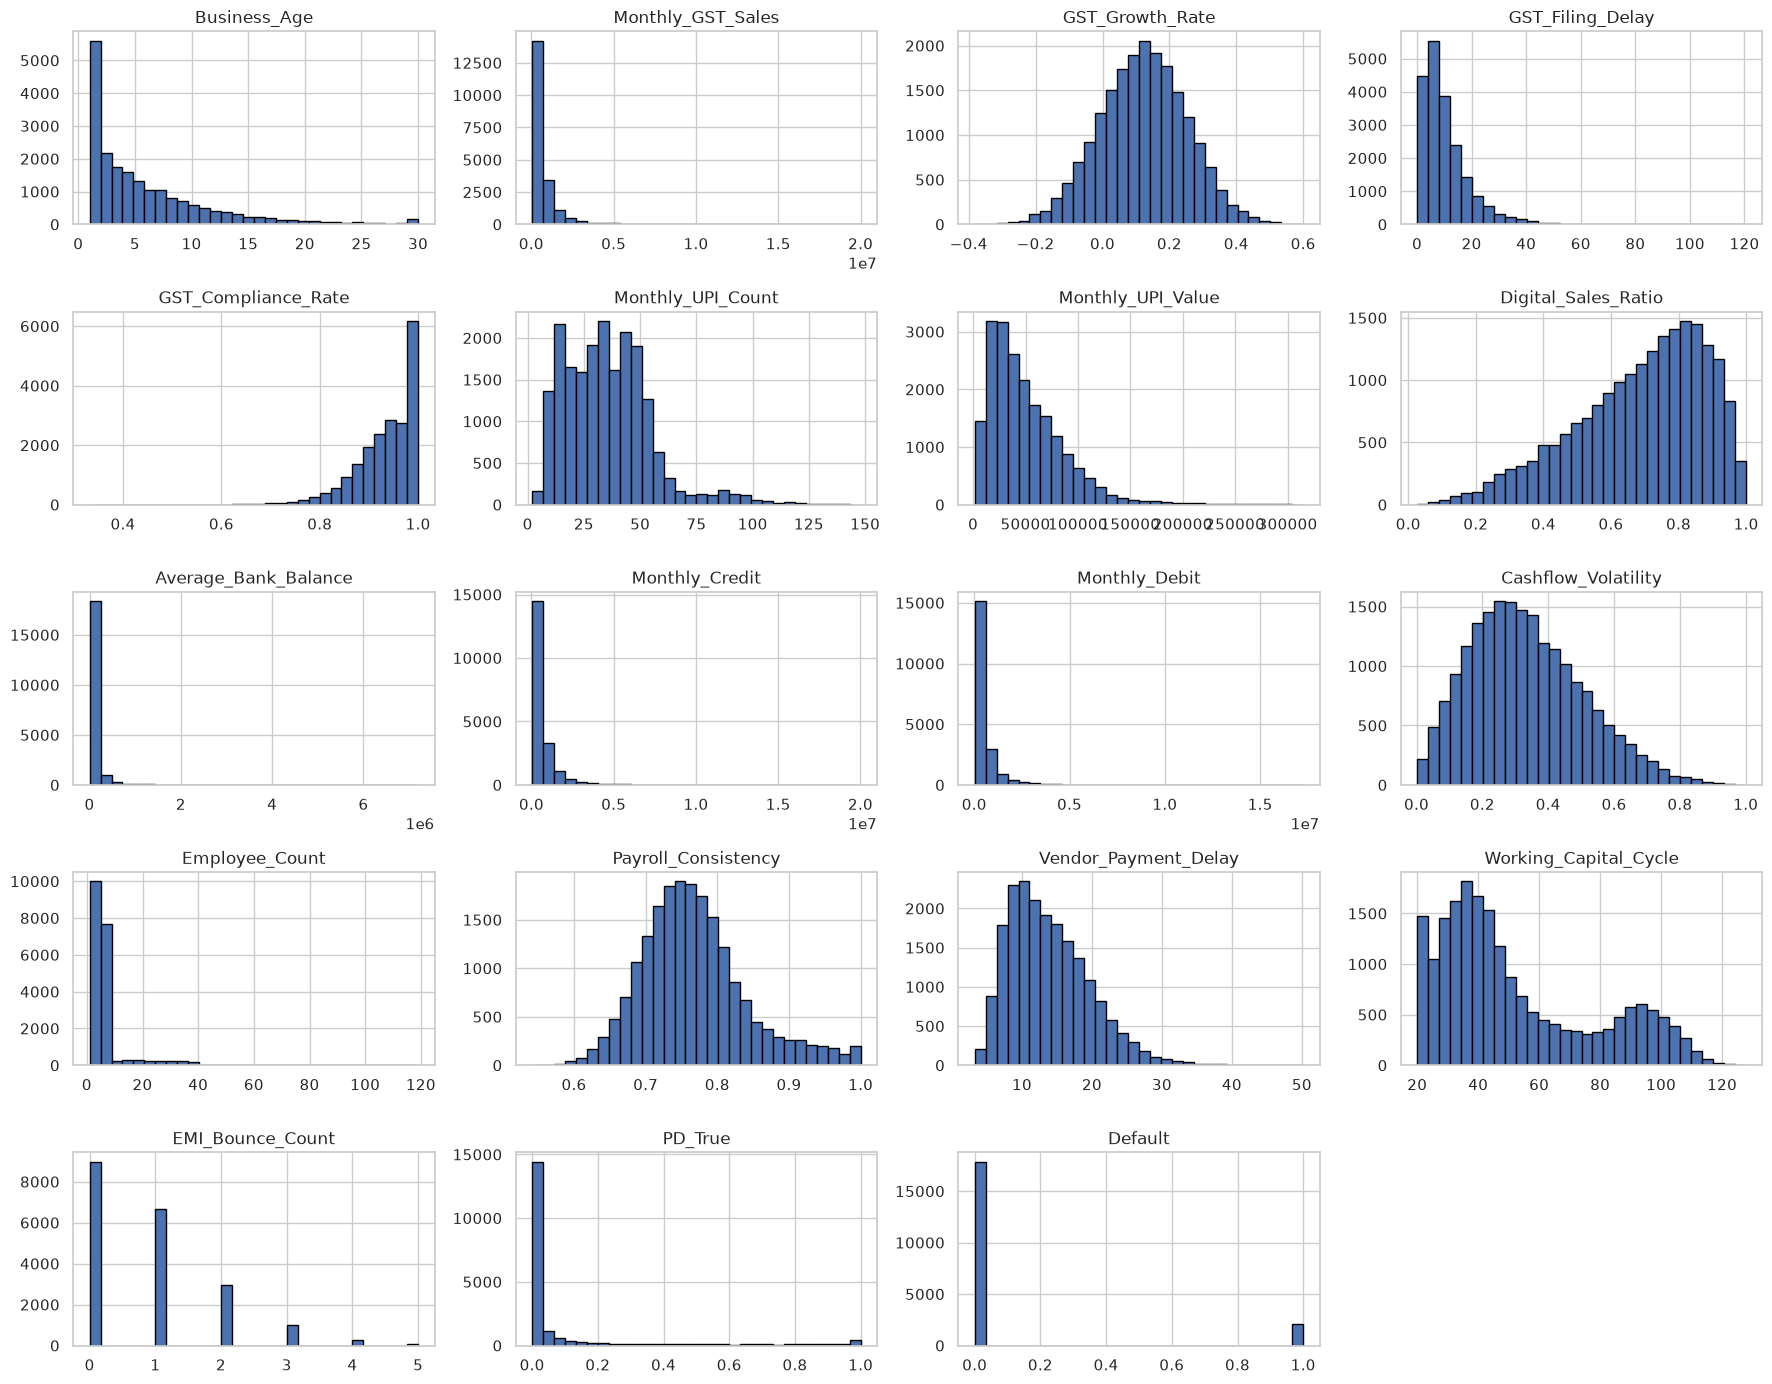

In [24]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(
    figsize=(18,14),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

## Correlation Heatmap

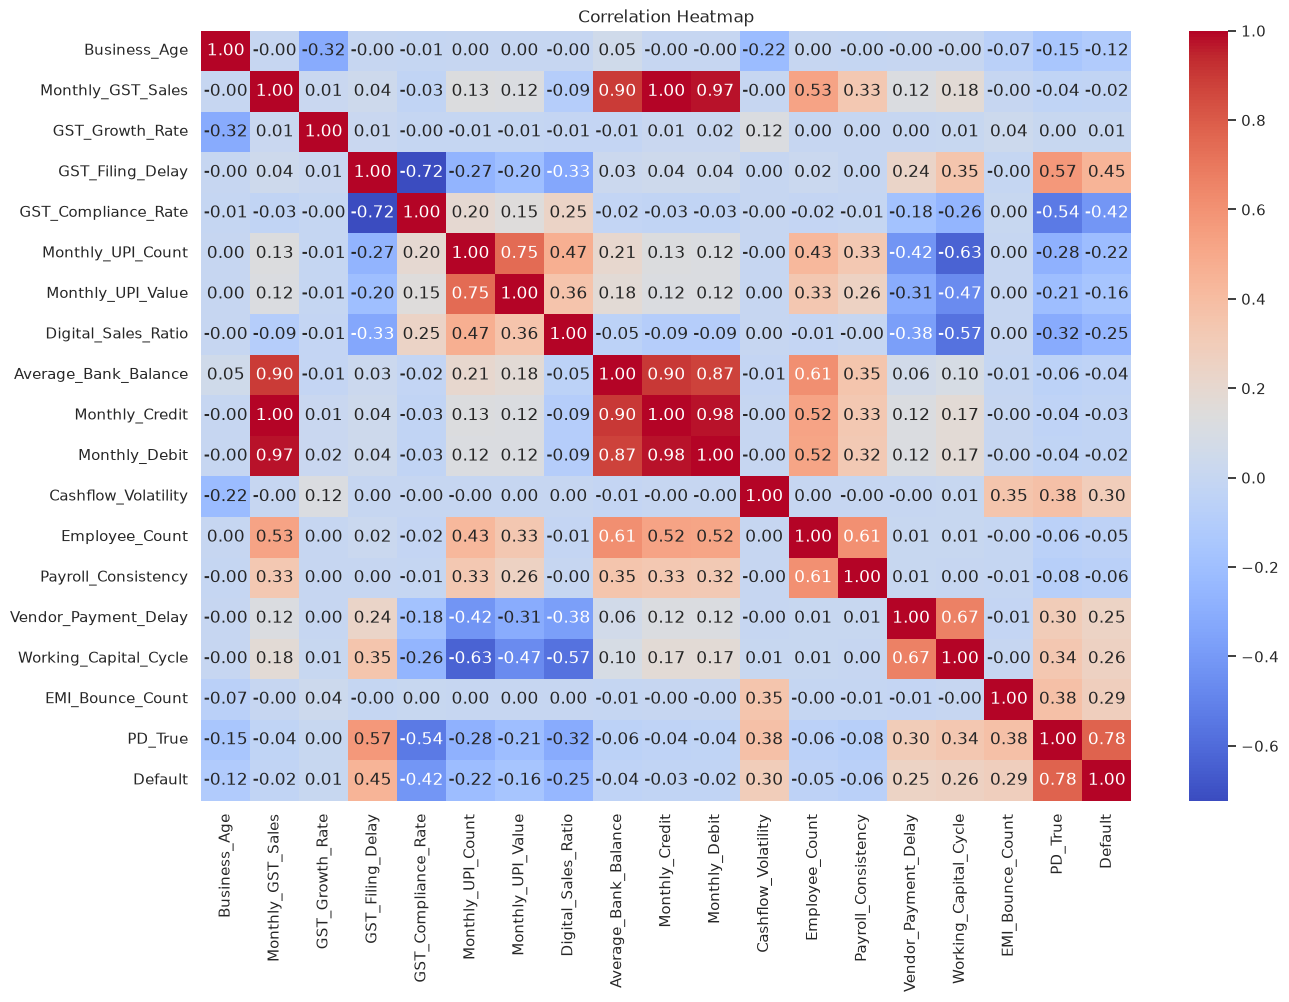

In [25]:
plt.figure(figsize=(15,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Boxplots vs Default

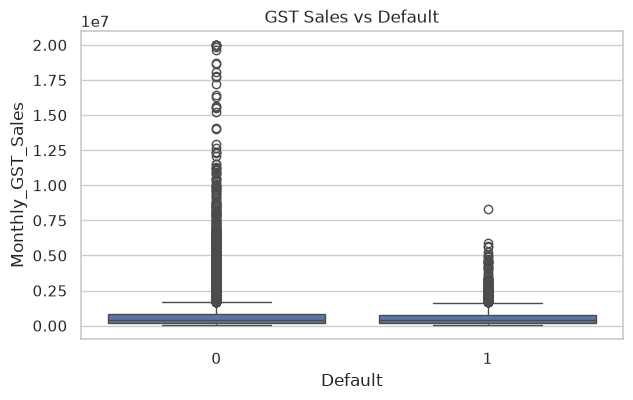

In [28]:
#GST Sales
plt.figure(figsize=(7,4))

sns.boxplot(data=df, x="Default", y="Monthly_GST_Sales")

plt.title("GST Sales vs Default")
plt.show()

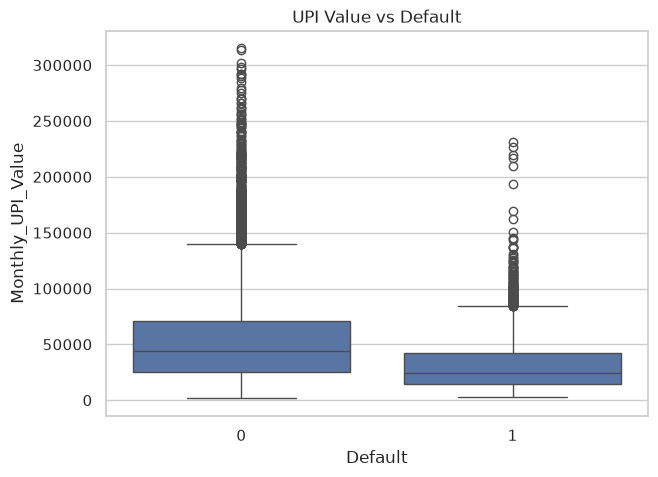

In [29]:
#UPI Value
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Default", y="Monthly_UPI_Value")
plt.title("UPI Value vs Default")
plt.show()

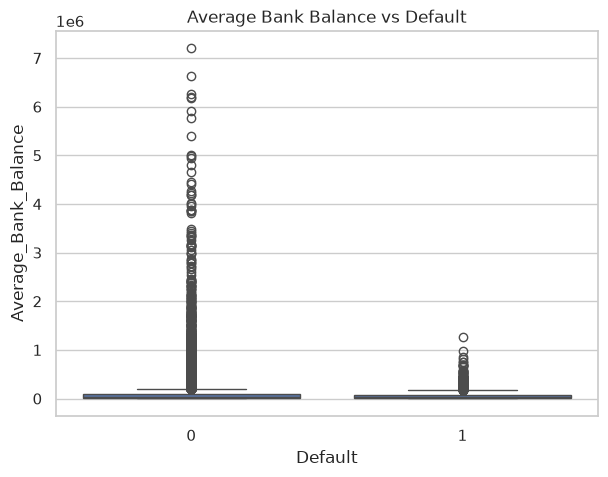

In [30]:
# Average Bank Balance
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Default", y="Average_Bank_Balance")
plt.title("Average Bank Balance vs Default")
plt.show()

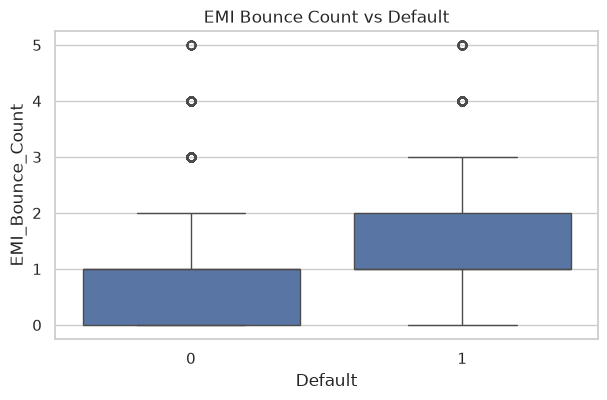

In [32]:
# EMI Bounce Count
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Default", y="EMI_Bounce_Count")

plt.title("EMI Bounce Count vs Default")
plt.show()

## Categorical Features

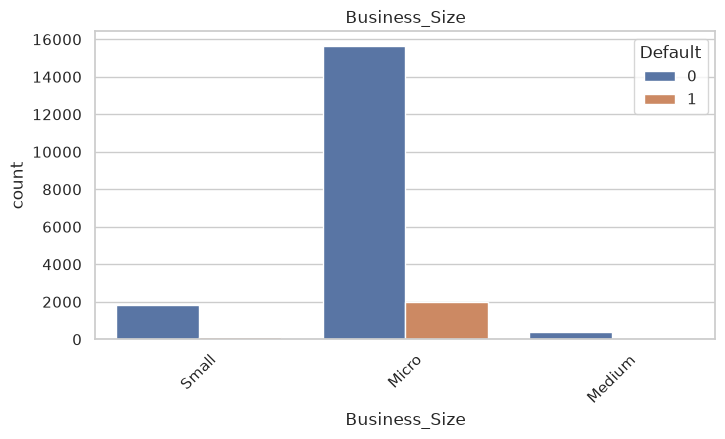

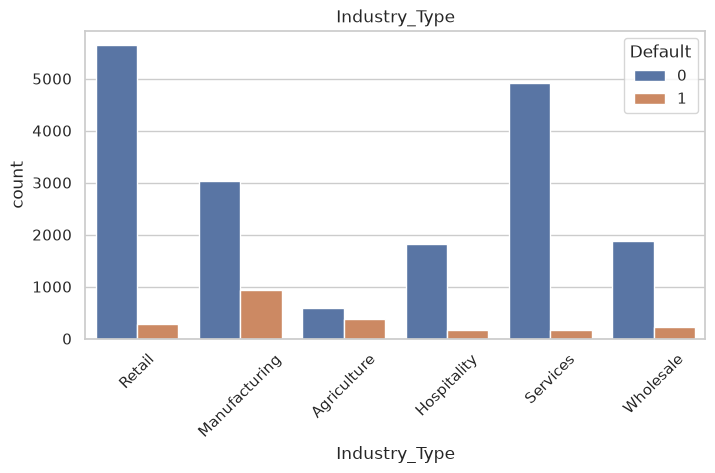

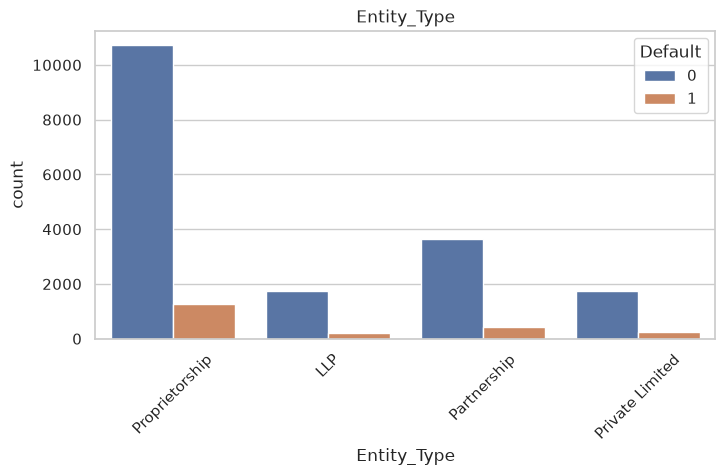

In [33]:
cat_cols = ["Business_Size", "Industry_Type", "Entity_Type"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="Default")
    plt.xticks(rotation=45)
    plt.title(col)

    plt.show()

## Pairplot (Important Features)

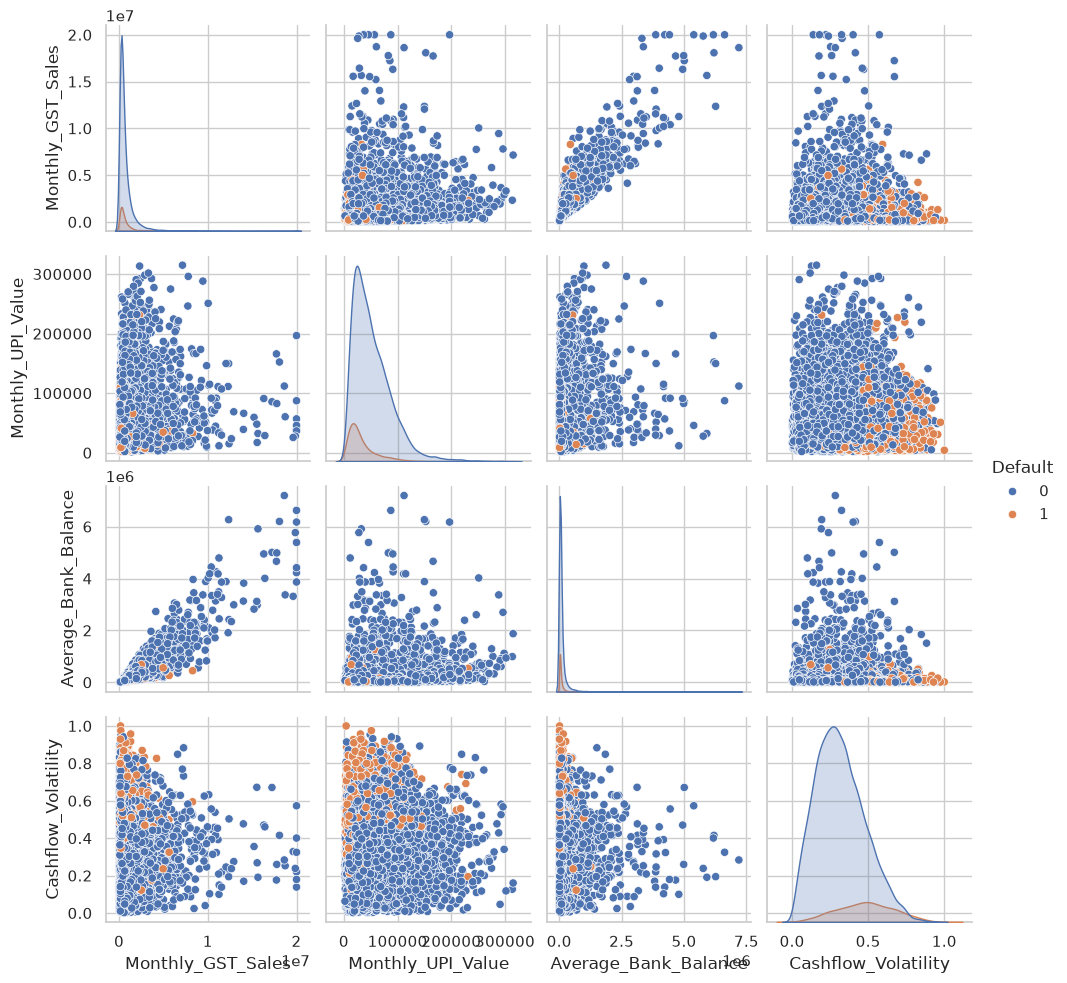

In [34]:
cols = ["Monthly_GST_Sales", "Monthly_UPI_Value",
        "Average_Bank_Balance", "Cashflow_Volatility", "Default"
       ]

sns.pairplot(df[cols], hue="Default")

plt.show()

## Feature Correlation with Target

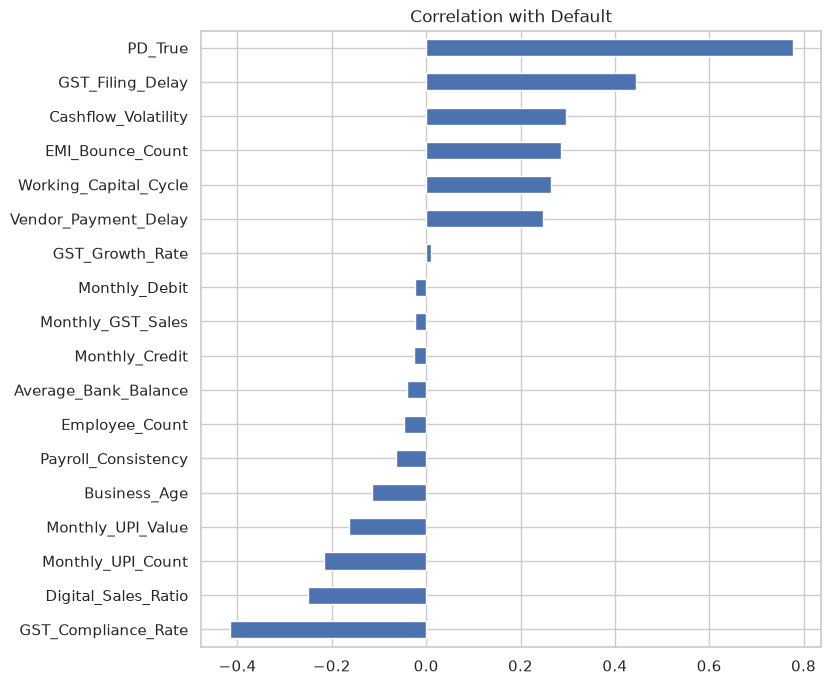

In [35]:
corr_target = df.corr(numeric_only=True)["Default"].sort_values()
plt.figure(figsize=(8,8))
corr_target.drop("Default").plot(kind="barh")
plt.title("Correlation with Default")
plt.show()

## Outlier Detection

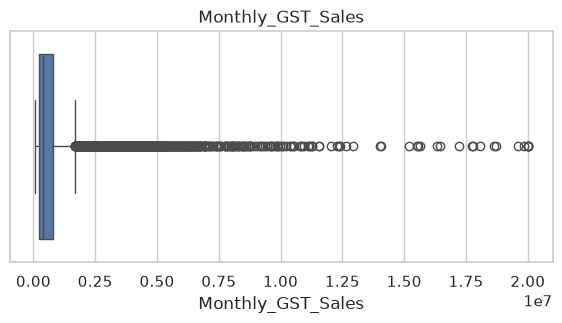

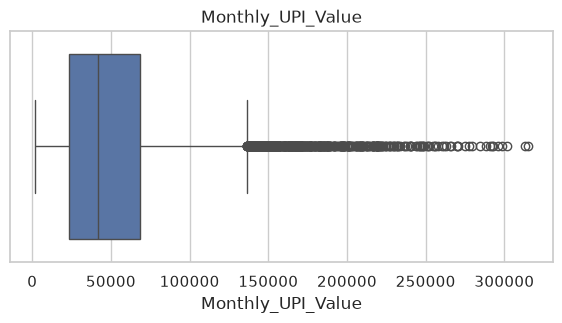

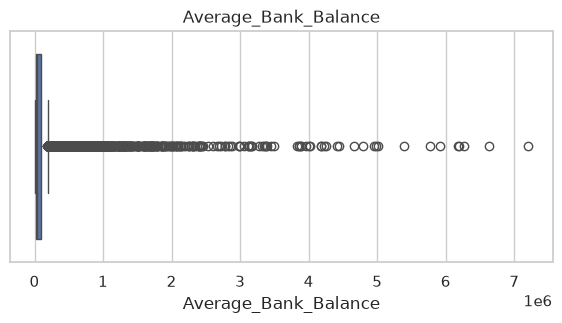

In [37]:
col_list = ["Monthly_GST_Sales", "Monthly_UPI_Value", "Average_Bank_Balance"]
for col in col_list:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Class balance

In [38]:
class_percent = df["Default"].value_counts(normalize=True)*100
print(class_percent)

Default
0    89.31
1    10.69
Name: proportion, dtype: float64
